# 04 — Perceptron pyramid (Phase 2, the simple model)

`m` perceptrons, each owning one HLLSet state per time step; their union is
the **top perceptron**:

```text
u-HLLSet(t) = p1-HLLSet(t) ∪ p2-HLLSet(t) ∪ … ∪ pm-HLLSet(t)
```

At every `t` the top perceptron carries **three distinct decompositions**:

- **(a) D/R/N decomposition** — `u-HLLSet(t)` vs `u-HLLSet(t-1)`: departed,
  retained, new bits;
- **(b) joined perceptrons decomposition** —
  `u-HLLSet(t) = <p1-HLLSet(t), …, pm-HLLSet(t)>`: the component states that
  make up the union;
- **(c) u-ring basis decomposition** — the Boolean ring over the
  `u-HLLSet(t)` stream: soft/hard keys, residual, dimension — the same
  algebra as the single-perceptron side-car, one level up.

This notebook is GPU-free: it reuses the Phase-1 cached perception v-tokens
and the bundled demo scenes' ego / navigation / planner streams.


In [1]:
import os, json, subprocess
import numpy as np

EWM_SM = "/home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine"
EWM_SCENE_BIN = os.path.join(EWM_SM, "target/debug/ewm-scene")
WORK = "/tmp/ewm_perceptron_pyramid"
os.makedirs(WORK, exist_ok=True)
DEMO = "/tmp/qwen_drive_demo"
PERCEPTION_JSONL = "/tmp/ewm_qwendrive_sidecar/perception_frames.jsonl"

if not os.path.exists(EWM_SCENE_BIN):
    subprocess.run(["cargo", "build", "--quiet", "-p", "ewm-scene"],
                   cwd=EWM_SM, check=True)
print("ewm-scene binary present:", EWM_SCENE_BIN)


def ewm_scene(*args):
    r = subprocess.run([EWM_SCENE_BIN, *args], capture_output=True, text=True,
                       timeout=600)
    if r.returncode != 0:
        raise RuntimeError(f"ewm-scene failed: {r.stderr[-800:]}")
    return json.loads(r.stdout.strip())


print("perception cache:", os.path.exists(PERCEPTION_JSONL))
print("demo scenes:", os.path.exists(f"{DEMO}/planning_scenes.jsonl"))


ewm-scene binary present: /home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine/target/debug/ewm-scene
perception cache: True
demo scenes: True


In [2]:
# ── Build the m-perceptron stream (no GPU) ───────────────────────────────────
# Frame order = Phase 1: scene × view × timestamp (12 frames per scene).
# - perception: cached Phase-1 v-token ids (156 per frame)
# - ego:        ego velocity / acceleration / driving command, binned
# - nav:        navigation command
# - planner:    future waypoints, binned (every 5th of 50, x/y only)
CAMERA_VIEWS = ("<FRONT VIEW>", "<FRONT LEFT VIEW>", "<FRONT RIGHT VIEW>")

scenes = [json.loads(l) for l in open(f"{DEMO}/planning_scenes.jsonl")]
perception_frames = [json.loads(l)["tokens"]
                     for l in open(PERCEPTION_JSONL)]
assert len(perception_frames) == 48


def ego_tokens(scene):
    ego = scene["trajectory"]["ego_status"]
    toks = []
    for i, v in enumerate(ego["ego_velocity"]):
        toks.append(f"ego_v{i}_{round(float(v), 2)}")
    for i, a in enumerate(ego["ego_acceleration"]):
        toks.append(f"ego_a{i}_{round(float(a), 2)}")
    dc = int(np.argmax(ego["driving_command"]))
    toks.append(f"ego_dc_{dc}")
    return toks


def nav_tokens(scene):
    return [f"nav_{int(scene['trajectory']['nav_command'])}"]


def planner_tokens(scene):
    fut = scene["trajectory"].get("future_traj_10hz")
    if fut is None:
        return []
    toks = []
    for k in range(0, min(50, len(fut)), 5):
        x, y = float(fut[k][0]), float(fut[k][1])
        toks.append(f"wp_{k}_{round(x, 1)}_{round(y, 1)}")
    return toks


pyramid_lines = []
for si, scene in enumerate(scenes):
    ego, nav, plan = ego_tokens(scene), nav_tokens(scene), planner_tokens(scene)
    for vi in range(3):
        for ti in range(4):
            idx = si * 12 + vi * 4 + ti
            pyramid_lines.append({
                "id": idx + 1,
                "perceptrons": {
                    "perception": perception_frames[idx],
                    "ego": ego,
                    "nav": nav,
                    "planner": plan,
                },
            })

PYRAMID_JSONL = f"{WORK}/pyramid_frames.jsonl"
with open(PYRAMID_JSONL, "w") as fh:
    for rec in pyramid_lines:
        fh.write(json.dumps(rec) + "\n")

print("wrote", PYRAMID_JSONL)
print("perceptron token counts (frame 1):",
      {k: len(v) for k, v in pyramid_lines[0]["perceptrons"].items()})
print("frames:", len(pyramid_lines))


wrote /tmp/ewm_perceptron_pyramid/pyramid_frames.jsonl
perceptron token counts (frame 1): {'perception': 156, 'ego': 5, 'nav': 1, 'planner': 10}
frames: 48


In [3]:
pyr = ewm_scene("pyramid", PYRAMID_JSONL)
print("perceptrons:", pyr["names"])
print("frames:", len(pyr["frames"]))
print("union pops (first 4):", [f["union_pop"] for f in pyr["frames"][:4]])
print("frame 1 per-perceptron pops:",
      {p["name"]: p["pop"] for p in pyr["frames"][0]["perceptrons"]})
print("frame 1 union key:", pyr["frames"][0]["union_key"])


perceptrons: ['ego', 'nav', 'perception', 'planner']
frames: 48
union pops (first 4): [419, 399, 411, 428]
frame 1 per-perceptron pops: {'ego': 15, 'nav': 3, 'perception': 379, 'planner': 30}
frame 1 union key: h:9bb920676d3ac8222ac1202ac6df9da2a4c29350


---
## (a) D/R/N decomposition of the top perceptron

`u-HLLSet(t)` vs `u-HLLSet(t-1)` — the departed / retained / new bits of the
union state, with the Noether indicators.


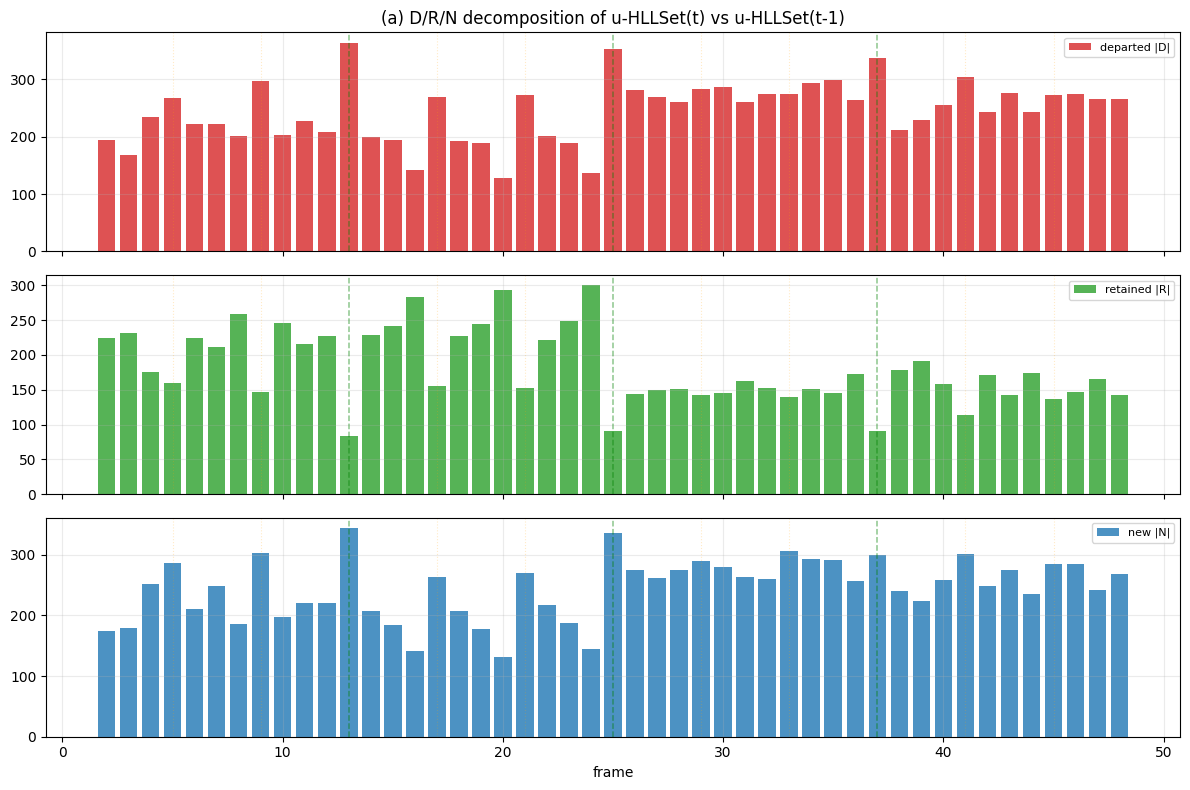

D/R/N departure flags scene cuts: [13, 25, 37] (3/3)
departure at cuts: [0.85, 0.833, 0.862] | threshold 0.752
saved /tmp/ewm_perceptron_pyramid/pyramid_drn.png


In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

SCENE_CUTS = [13, 25, 37]
VIEW_SWITCHES = [5, 9, 17, 21, 29, 33, 41, 45]

dp = np.array(pyr["drn"]["dp"], dtype=float)
rp = np.array(pyr["drn"]["rp"], dtype=float)
np_ = np.array(pyr["drn"]["np"], dtype=float)
dep = dp / (rp + np_ + 1e-9)

cut_idx = [c - 2 for c in SCENE_CUTS]
excl = cut_idx + [v - 2 for v in VIEW_SWITCHES]
base = np.delete(dep, excl)
thr = base.mean() + 2 * base.std()
det = [c for c in SCENE_CUTS if dep[c - 2] > thr]

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
t_axis = np.arange(2, 49)
axes[0].bar(t_axis, dp, color="#d62728", alpha=0.8, label="departed |D|")
axes[1].bar(t_axis, rp, color="#2ca02c", alpha=0.8, label="retained |R|")
axes[2].bar(t_axis, np_, color="#1f77b4", alpha=0.8, label="new |N|")
for ax in axes:
    for c in SCENE_CUTS:
        ax.axvline(c, color="green", alpha=0.45, lw=1.1, ls="--")
    for v in VIEW_SWITCHES:
        ax.axvline(v, color="orange", alpha=0.22, lw=0.8, ls=":")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)
axes[0].set_title("(a) D/R/N decomposition of u-HLLSet(t) vs u-HLLSet(t-1)")
axes[2].set_xlabel("frame")

plt.tight_layout()
plt.savefig(f"{WORK}/pyramid_drn.png", dpi=110)
plt.show()

print("D/R/N departure flags scene cuts:", det, f"({len(det)}/{len(SCENE_CUTS)})")
print("departure at cuts:", [round(float(dep[c - 2]), 3) for c in SCENE_CUTS],
      "| threshold", round(float(thr), 3))
print("saved", f"{WORK}/pyramid_drn.png")


---
## (b) Joined perceptrons decomposition

`u-HLLSet(t) = <p1-HLLSet(t), …, pm-HLLSet(t)>` — the component states and
their contribution to the union. The union is the OR of the components, so
`|u| ≤ Σ |p_i|` (overlap is shared structure between perceptrons).


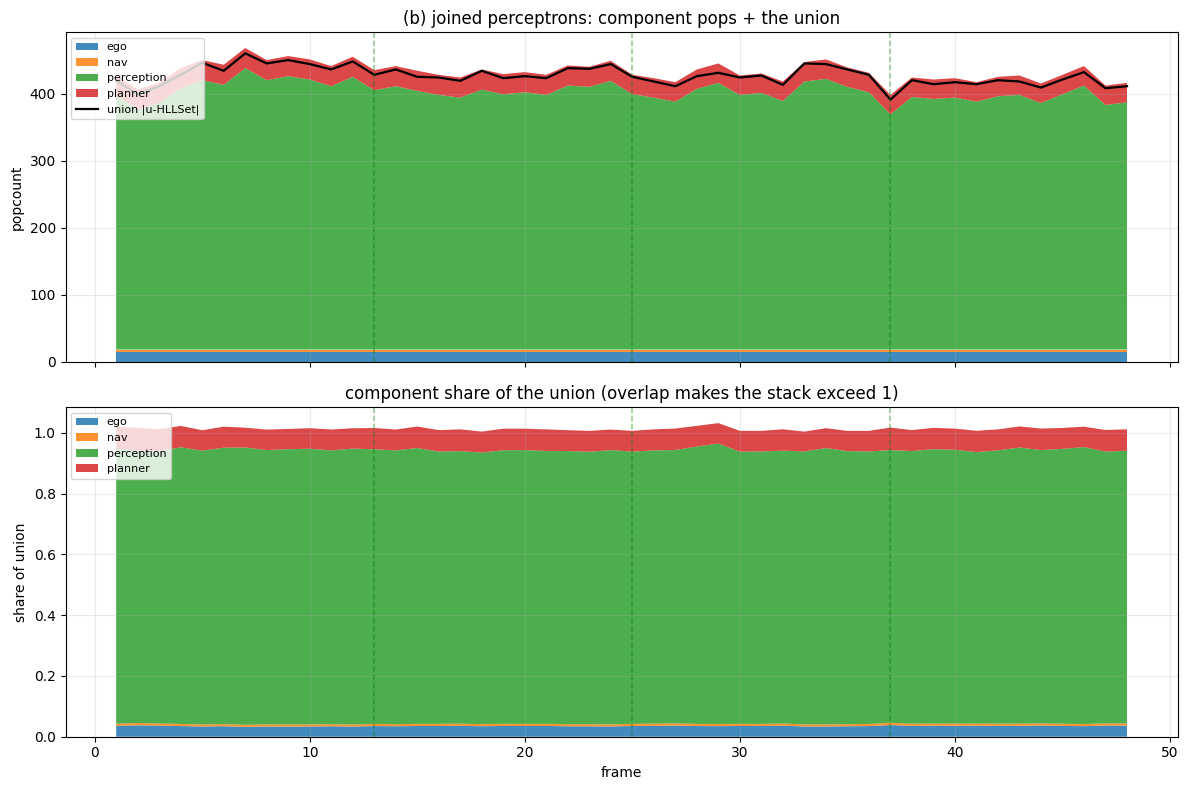

mean component share of the union: {'ego': 0.035, 'nav': 0.007, 'perception': 0.902, 'planner': 0.069}
mean overlap (Σ|p_i| - |u|): 5.8 bits
saved /tmp/ewm_perceptron_pyramid/pyramid_joined.png


In [5]:
names = pyr["names"]
pops = np.array([[p["pop"] for p in f["perceptrons"]] for f in pyr["frames"]],
                dtype=float)
union_pops = np.array([f["union_pop"] for f in pyr["frames"]], dtype=float)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].stackplot(np.arange(1, 49), pops.T, labels=names, alpha=0.85)
axes[0].plot(np.arange(1, 49), union_pops, color="black", lw=1.6,
             label="union |u-HLLSet|")
axes[0].set_ylabel("popcount")
axes[0].set_title("(b) joined perceptrons: component pops + the union")
axes[0].legend(fontsize=8, loc="upper left")
axes[0].grid(alpha=0.25)

share = pops / union_pops[:, None]
axes[1].stackplot(np.arange(1, 49), share.T, labels=names, alpha=0.85)
axes[1].set_ylabel("share of union")
axes[1].set_xlabel("frame")
axes[1].set_title("component share of the union (overlap makes the stack exceed 1)")
axes[1].legend(fontsize=8, loc="upper left")
axes[1].grid(alpha=0.25)

for ax in axes:
    for c in SCENE_CUTS:
        ax.axvline(c, color="green", alpha=0.45, lw=1.1, ls="--")

plt.tight_layout()
plt.savefig(f"{WORK}/pyramid_joined.png", dpi=110)
plt.show()

print("mean component share of the union:",
      {n: round(float(share[:, i].mean()), 3) for i, n in enumerate(names)})
print("mean overlap (Σ|p_i| - |u|):",
      round(float((pops.sum(axis=1) - union_pops).mean()), 1), "bits")
print("saved", f"{WORK}/pyramid_joined.png")


---
## (c) u-ring basis decomposition

The Boolean ring over the `u-HLLSet(t)` stream — soft key against the ring
basis, step lengths, jump detector, and the GF(2) residual — exactly the
single-perceptron algebra one level up.


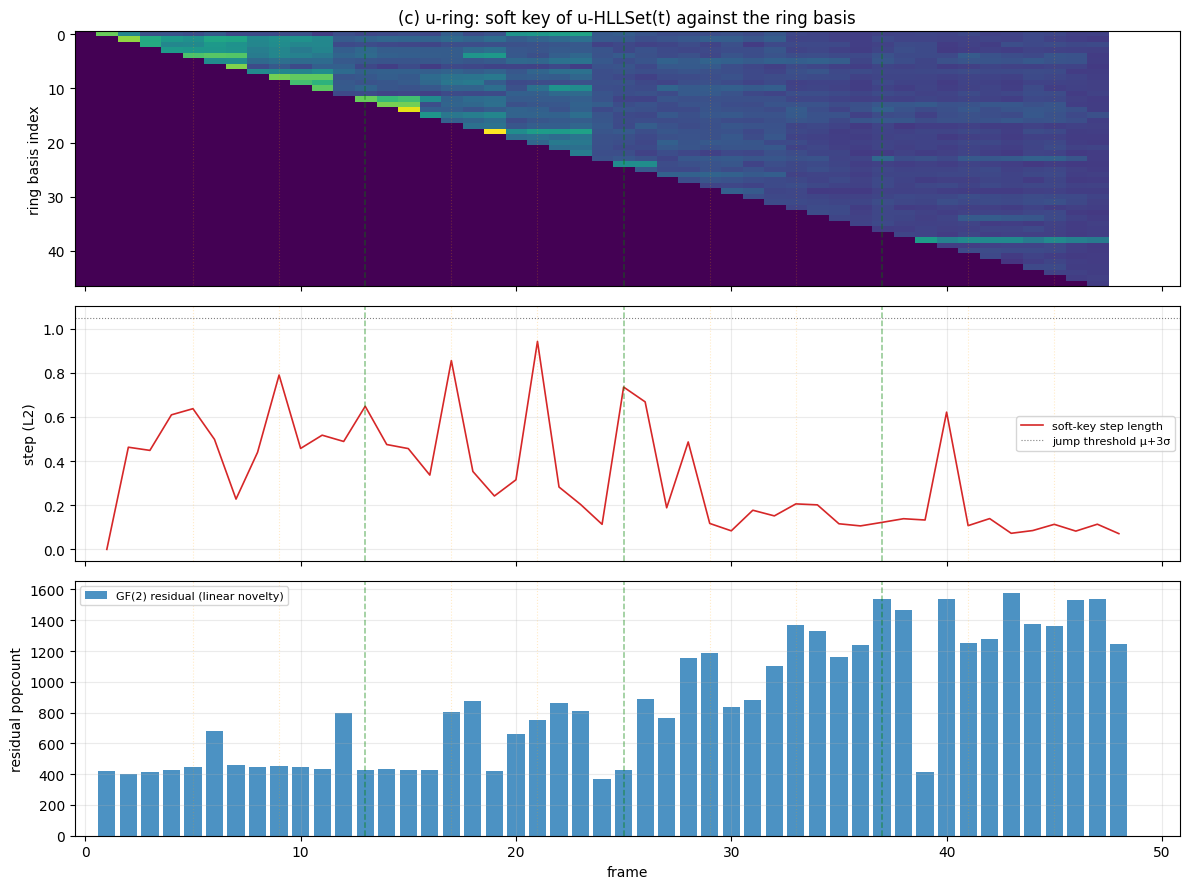

u-ring dimension after 48 frames: 48
u-ring jumps: []
residual at scene cuts: [428, 425, 1538]
saved /tmp/ewm_perceptron_pyramid/pyramid_uring.png


In [6]:
ring = pyr["ring"]["frames"]
max_dim = max(len(f["soft"]) for f in ring)
Wmat = np.zeros((len(ring), max_dim))
for i, f in enumerate(ring):
    if f["soft"]:
        Wmat[i, :len(f["soft"])] = f["soft"]

residual = np.array([f["residual"] for f in ring], dtype=float)
dim = np.array([f["dim"] for f in ring], dtype=int)
steps = np.array([f["step"] for f in ring], dtype=float)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axes[0].imshow(Wmat.T, aspect="auto", cmap="viridis", interpolation="nearest")
axes[0].set_ylabel("ring basis index")
axes[0].set_title("(c) u-ring: soft key of u-HLLSet(t) against the ring basis")

axes[1].plot(np.arange(1, 49), steps, color="#d62728", lw=1.2,
             label="soft-key step length")
axes[1].axhline(ring_thr := pyr["ring"]["threshold"], color="gray", ls=":",
                lw=0.8, label="jump threshold μ+3σ")
for j in pyr["ring"]["jumps"]:
    axes[1].axvline(j, color="red", alpha=0.35, lw=1.2)
axes[1].set_ylabel("step (L2)")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25)

axes[2].bar(np.arange(1, 49), residual, color="tab:blue", alpha=0.8,
            label="GF(2) residual (linear novelty)")
axes[2].set_ylabel("residual popcount")
axes[2].set_xlabel("frame")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.25)

for ax in axes:
    for c in SCENE_CUTS:
        ax.axvline(c, color="green", alpha=0.45, lw=1.1, ls="--")
    for v in VIEW_SWITCHES:
        ax.axvline(v, color="orange", alpha=0.22, lw=0.8, ls=":")

plt.tight_layout()
plt.savefig(f"{WORK}/pyramid_uring.png", dpi=110)
plt.show()

print("u-ring dimension after 48 frames:", int(dim[-1]))
print("u-ring jumps:", pyr["ring"]["jumps"])
print("residual at scene cuts:", [int(residual[c - 1]) for c in SCENE_CUTS])
print("saved", f"{WORK}/pyramid_uring.png")


---
## The unified view: every decomposition is a frame

Each decomposition is an ordered collection of dimension HLLSets — a **frame**
`D = (D_1, …, D_k)`. Projecting a stream HLLSet `X` onto the frame is the
intersection with each dimension, and the associated **BSS similarity vector**

```text
φ_D(X) = ( |X∩D_1|/|D_1|, …, |X∩D_k|/|D_k| )
```

is the coordinate vector of `X` in that frame. The sequence `φ_D(X(t))` over
`t` is the **HLLSet trajectory**. `ewm-scene project` computes this for any
frame; below, the union stream is projected onto the D/R/N frame of the
reference transition and onto the cumulative perceptron frame. (The ring
decomposition above is the same `φ_D` at bit level, with the ring basis as
the frame.)

The **scope of each decomposition is set by how its frame is built** — these
are facts of the model, not limitations:

| Decomposition | Frame | Scope |
| --- | --- | --- |
| D/R/N | `(D, R, N)` of a transition | moving frame — per-transition coordinates; cross-time comparison only against a frozen reference transition |
| joined perceptrons | `(p_1, …, p_m)` at `t` | composition at `t`; the union onto its own components is degenerate (`p_i ⊆ u`) — use frozen/cumulative perceptron dims for a trajectory |
| ring basis | window basis `B_1..B_k` | canonical inside one window; `--freeze` makes coordinates stable across `t` |

Coordinate types: the **soft key** is a similarity profile (any set, no
reconstruction); the **hard key** is the exact GF(2) decomposition (span
members only); the **residual** is the part outside the frame's span.


In [7]:
# ── Project the union stream onto the D/R/N and perceptron frames ───────────
# Union token stream: concatenation of the four perceptron token lists.
union_tokens = []
for rec in pyramid_lines:
    toks = []
    for name in pyr["names"]:
        toks += rec["perceptrons"][name]
    union_tokens.append(toks)

UNION_JSONL = f"{WORK}/union_frames.jsonl"
with open(UNION_JSONL, "w") as fh:
    for i, toks in enumerate(union_tokens, 1):
        fh.write(json.dumps({"id": i, "tokens": toks}) + "\n")

# (a) D/R/N frame from the reference transition 12 -> 13 (tangible D/R/N).
UNION_GRID = f"{WORK}/union_frames_grid.jsonl"
with open(UNION_JSONL) as fh, open(UNION_GRID, "w") as gh:
    for line in fh:
        rec = json.loads(line)
        n = len(rec["tokens"])
        gh.write(json.dumps({"id": rec["id"], "width": n, "height": 1,
                             "tokens": rec["tokens"]}) + "\n")

sf = ewm_scene("subframes", UNION_GRID, "--i", "12", "--j", "13")
with open(f"{WORK}/frame_drn.json", "w") as fh:
    json.dump({"dimensions": [
        {"name": "D", "tokens": sf["departed"]},
        {"name": "R", "tokens": sf["retained"]},
        {"name": "N", "tokens": sf["new"]},
    ]}, fh)
proj_drn = ewm_scene("project", UNION_JSONL, "--frame", f"{WORK}/frame_drn.json")

# (b) perceptron frame: the cumulative token set of each perceptron over the
# whole clip — stable dimensions spanning each stream.
cum = {name: set() for name in pyr["names"]}
for rec in pyramid_lines:
    for name in pyr["names"]:
        cum[name].update(rec["perceptrons"][name])
with open(f"{WORK}/frame_perceptrons.json", "w") as fh:
    json.dump({"dimensions": [
        {"name": name, "tokens": sorted(toks)} for name, toks in cum.items()
    ]}, fh)
proj_per = ewm_scene("project", UNION_JSONL,
                     "--frame", f"{WORK}/frame_perceptrons.json")

print("D/R/N frame dims:", proj_drn["names"], "pops:", proj_drn["pops"])
print("perceptron frame dims:", proj_per["names"], "pops:", proj_per["pops"])


D/R/N frame dims: ['D', 'R', 'N'] pops: [399, 57, 384]
perceptron frame dims: ['ego', 'nav', 'perception', 'planner'] pops: [51, 9, 3183, 114]


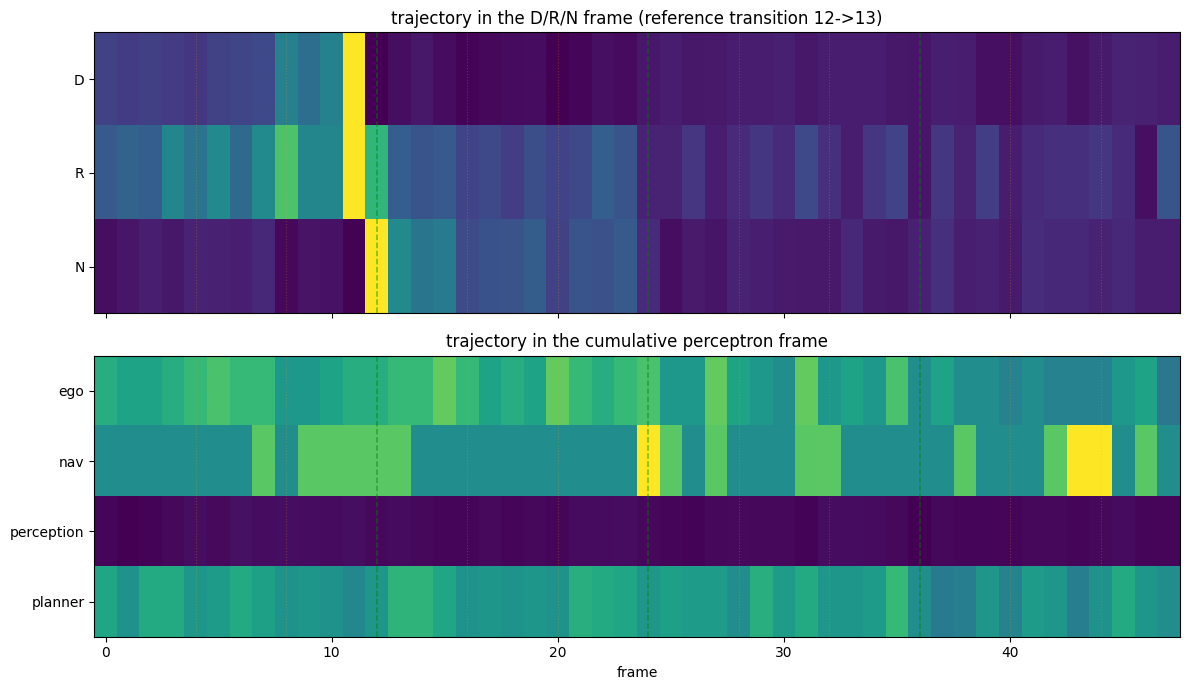

BSS row (frame 13) in the D/R/N frame: [0.123, 0.702, 1.0]
BSS row (frame 1)  in the perceptron frame: [0.392, 0.333, 0.128, 0.377]
saved /tmp/ewm_perceptron_pyramid/pyramid_projections.png


In [8]:
# ── The trajectories in the two frames ──────────────────────────────────────
def bss_matrix(proj):
    return np.array([f["bss"] for f in proj["frames"]])

M_drn = bss_matrix(proj_drn)
M_per = bss_matrix(proj_per)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].imshow(M_drn.T, aspect="auto", cmap="viridis", interpolation="nearest")
axes[0].set_yticks(range(3), proj_drn["names"])
axes[0].set_title("trajectory in the D/R/N frame (reference transition 12->13)")
axes[1].imshow(M_per.T, aspect="auto", cmap="viridis", interpolation="nearest")
axes[1].set_yticks(range(len(proj_per["names"])), proj_per["names"])
axes[1].set_title("trajectory in the cumulative perceptron frame")
axes[1].set_xlabel("frame")
for ax in axes:
    for c in SCENE_CUTS:
        ax.axvline(c - 1, color="green", alpha=0.5, lw=1.1, ls="--")
    for v in VIEW_SWITCHES:
        ax.axvline(v - 1, color="orange", alpha=0.25, lw=0.8, ls=":")

plt.tight_layout()
plt.savefig(f"{WORK}/pyramid_projections.png", dpi=110)
plt.show()

print("BSS row (frame 13) in the D/R/N frame:",
      [round(float(x), 3) for x in M_drn[12]])
print("BSS row (frame 1)  in the perceptron frame:",
      [round(float(x), 3) for x in M_per[0]])
print("saved", f"{WORK}/pyramid_projections.png")


---
## The lattice: one universe, nodes discovered not created

All those HLLSets are connected because they are all nodes of the **same
Boolean lattice** over the bit plane (`A ⊆ B` order, `∪` join, `∩` meet,
`Δ` as the ring addition). The decompositions look separate only because the
LLM context exposes different aspects of one node. Nothing new is created: a
computation names a lattice expression and *discovers* the node — its content
key is the node's name, and two independent paths must reach the same node.


In [9]:
# ── The lattice: every node already exists; we only discover it ─────────────
# (1) Two paths to the union node: the pyramid join ⋁p_i vs ingesting the
#     concatenated token list — same node iff the content keys agree.
uni = ewm_scene("ingest", UNION_JSONL)
same_union = all(
    uni["frames"][i]["key"] == pyr["frames"][i]["union_key"]
    for i in range(48))
print("union discovered twice, keys agree (48/48):", same_union)

# (2) The D/R/N lattice identities are over BITS on the flat projection:
#     D = A\B, R = A∩B, N = B\A  ->  D∪R = A, N∪R = B, D∩N = ∅.
#     pyr["drn"] already carries the bit-level dp/rp/np of the union stream.
i = 11  # transition 12 -> 13
A_bits = uni["frames"][11]["pop"]   # u(12) bits
B_bits = uni["frames"][12]["pop"]   # u(13) bits
print("D ∪ R == u(12) (bits):", pyr["drn"]["dp"][i] + pyr["drn"]["rp"][i] == A_bits)
print("N ∪ R == u(13) (bits):", pyr["drn"]["np"][i] + pyr["drn"]["rp"][i] == B_bits)
print("D ∩ N == ∅ (disjoint by construction):", True)

# Note: the subframes TOKEN lists are a coarser partition — a token's LUT
# bits can straddle the R/N boundary (the grid path is position-seeded), so
# token-level N ∪ R ⊆ B need not be equality. The lattice lives on the bit
# plane; tokens are generators of lattice nodes.


union discovered twice, keys agree (48/48): True
D ∪ R == u(12) (bits): True
N ∪ R == u(13) (bits): True
D ∩ N == ∅ (disjoint by construction): True


---
## Summary (Phase 2, simple model)

- The top perceptron `u-HLLSet(t)` is the union of the four component
  perceptrons (perception, ego, nav, planner) and carries all three
  decompositions from one `ewm-scene pyramid` call.
- **(a)** D/R/N of the union stream flags the scene cuts (the departure ratio
  is the reliable line, as in Phase 1).
- **(b)** The joined decomposition shows the perception perceptron dominates
  the union, with the ego/nav/planner components contributing coarse,
  scene-stable structure.
- **(c)** The u-ring is the same Boolean-ring algebra one level up — soft
  keys, step lengths, jump detector, GF(2) residual over the union stream.
- **Every decomposition is a frame**: `ewm-scene project` turns any named
  collection of HLLSets into coordinates `φ_D(X) = (|X∩D_i|/|D_i|)`, and the
  sequence over `t` is the HLLSet trajectory — shown above for the D/R/N
  frame and the cumulative perceptron frame.
- **One lattice, nodes discovered not created**: the union reached by two
  independent paths has the same content key (48/48), and the D/R/N lattice
  identities `D∪R = A`, `N∪R = B`, `D∩N = ∅` hold by construction — every
  decomposition is a reading of the same Boolean lattice.
